# 📊 Data Preparation Overview

This notebook executes the **end-to-end data preparation pipeline** for Airlytics’ Loyalty Program Analytics, aligned with the **6 Data Science objectives**.

---

### 🔧 Key Steps

#### **1. Data Cleaning**
* Verified no duplicates (handled in ETL process).
* Imputed missing values 
* Handled outliers in numerical fields 

#### **2. Data Transformation**
* Encoded categorical variables (**gender, education, marital_status**, etc.).
* Prepared numerical features for modeling (e.g., scaling/normalization, if needed).

#### **3. Feature Engineering & Selection**
* Created **objective-specific features** (e.g., redemption rate, tenure, points-to-tier).
* Selected relevant features per Data Science objective.

---

### 💾 Output: Final Datasets

Final datasets are exported as **6 CSV files**, one for each Data Science objective:

* `ds_objective_1_redemption.csv`
* `ds_objective_2_churn.csv`
* `ds_objective_3_clv.csv`
* `ds_objective_4_tier_progression.csv`
* `ds_objective_5_traveler_profile.csv`
* `ds_objective_6_geo_equity.csv`

> **Note:** All datasets are built from cleaned dimension tables (**customer, geography**) and the fact table (**loyalty_behavior**), ensuring consistency and traceability.

### Connection DW

In [ ]:
import pyodbc
print(pyodbc.drivers())

: 

In [2]:
import pyodbc
import pandas as pd

# connection string (Windows Authentication)
conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=.;"
    "DATABASE=DWH_AIRLINE;"
    "Trusted_Connection=yes;"
)

# connect
try:
    conn = pyodbc.connect(conn_str, timeout=5)
    print("Connected to DW_AIRLINE on ASMA-BH (Windows Authentication).")
except Exception as e:
    print("Connection failed:", e)
    conn = None
conn = pyodbc.connect(conn_str)

df_loyalty = pd.read_sql("SELECT * FROM fact_customer_loyalty;", conn)
df_customer = pd.read_sql("SELECT * FROM dim_customer;", conn)
df_feedback = pd.read_sql("SELECT * FROM dim_feedback;", conn)
df_flight = pd.read_sql("SELECT * FROM dim_flight;", conn)
df_geography = pd.read_sql("SELECT * FROM dim_geography;", conn)
df_loyalty_program = pd.read_sql("SELECT * FROM dim_loyalty_program;", conn)
df_services = pd.read_sql("SELECT * FROM dim_services;", conn)
df_dates = pd.read_sql("SELECT * FROM DimDates;", conn)

conn.close()

In [84]:
output_path = "fact_customer_loyalty.csv"

df_loyalty.to_csv(output_path, index=False)

print("CSV file created:", output_path)

In [3]:
import pandas as pd

# Path of the Excel file you want to create
output_path = "DW_airline_dump.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_customer.to_excel(writer, sheet_name="dim_customer", index=False)
    df_feedback.to_excel(writer, sheet_name="dim_feedback", index=False)
    df_flight.to_excel(writer, sheet_name="dim_flight", index=False)
    df_geography.to_excel(writer, sheet_name="dim_geography", index=False)
    df_loyalty_program.to_excel(writer, sheet_name="dim_loyalty_program", index=False)
    df_services.to_excel(writer, sheet_name="dim_services", index=False)
    df_dates.to_excel(writer, sheet_name="dim_dates", index=False)

print("Excel file created:", output_path)


In [ ]:
import pandas as pd

input_path = "DW_airline_dump.xlsx"
df_customer = pd.read_excel(input_path, sheet_name="dim_customer")
df_feedback = pd.read_excel(input_path, sheet_name="dim_feedback")
df_flight = pd.read_excel(input_path, sheet_name="dim_flight")
df_geography = pd.read_excel(input_path, sheet_name="dim_geography")
df_loyalty_program = pd.read_excel(input_path, sheet_name="dim_loyalty_program")
df_services = pd.read_excel(input_path, sheet_name="dim_services")
df_dates = pd.read_excel(input_path, sheet_name="dim_dates")

print("Import done.")


FileNotFoundError: [Errno 2] No such file or directory: 'DW_airline_dump.xlsx'

In [2]:
import pandas as pd

# Define file paths relative to current directory
files = {
    "customer": "cleaned_dim_customer_for_modeling.xlsx",
    "feedback": "cleaned_dim_feedback_for_modeling.xlsx",
    "flight": "cleaned_dim_flight_for_modeling.xlsx",
    "geography": "cleaned_dim_geography_for_modeling.csv",  # CSV!
    "loyalty_program": "cleaned_dim_loyalty_program_for_modeling.xlsx",
    "services": "cleaned_dim_services_for_modeling.xlsx",
    "master": "cleaned_master.csv",                         # CSV!
    "fact_customer_loyalty": "fact_customer_loyalty.csv"    # CSV!
}

# Load all files into a dictionary
dfs = {}

for name, path in files.items():
    if path.endswith('.xlsx'):
        dfs[name] = pd.read_excel(path)
    elif path.endswith('.csv'):
        dfs[name] = pd.read_csv(path)
    print(f"✅ Loaded: {name}")

# Optional: Assign each to its own variable (if needed for your analysis)
df_customer = dfs["customer"]
df_feedback = dfs["feedback"]
df_flight = dfs["flight"]
df_geography = dfs["geography"]
df_loyalty_program = dfs["loyalty_program"]
df_services = dfs["services"]
df_master = dfs["master"]
df_loyalty = dfs["fact_customer_loyalty"]

print("\n🎉 All cleaned datasets loaded successfully!")

✅ Loaded: customer
✅ Loaded: feedback
✅ Loaded: flight
✅ Loaded: geography
✅ Loaded: loyalty_program
✅ Loaded: services
✅ Loaded: master
✅ Loaded: fact_customer_loyalty

🎉 All cleaned datasets loaded successfully!


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5501104 entries, 0 to 5501103
Data columns (total 22 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Total_Flights                int64  
 1   Distance                     int64  
 2   Points_Accumulated           int64  
 3   Points_Redeemed              int64  
 4   Dollar_Cost_Points_Redeemed  int64  
 5   CLV                          float64
 6   Enrollment_Year              int64  
 7   Enrollment_Month             int64  
 8   Cancellation_Year            int64  
 9   Cancellation_Month           int64  
 10  Rating_value                 int64  
 11  salary                       float64
 12  education_encoded            int64  
 13  gender_encoded               int64  
 14  marital_status_encoded       int64  
 15  province_encoded             int64  
 16  city_encoded                 int64  
 17  class_encoded                int64  
 18  travel_type_encoded          int64  
 19  

In [5]:

import pyodbc
import pandas as pd

# connection string (Windows Authentication)
conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=.;"
    "DATABASE=DWH_AIRLINE;"
    "Trusted_Connection=yes;"
)

# connect
try:
    conn = pyodbc.connect(conn_str, timeout=5)
    print("Connected to DW_AIRLINE on ASMA-BH (Windows Authentication).")
except Exception as e:
    print("Connection failed:", e)
    conn = None

if conn is not None:
    query = """
    SELECT TABLE_SCHEMA, TABLE_NAME
    FROM INFORMATION_SCHEMA.TABLES
    WHERE TABLE_TYPE = 'BASE TABLE'
    ORDER BY TABLE_SCHEMA, TABLE_NAME
    """
    df_tables = pd.read_sql(query, conn)
    display(df_tables.head(50))   # shows up to first 50 rows
else:
    print("No active connection.")
conn.close()  


**2. Data Description & visualization**

In [6]:
df_loyalty.head()

In [7]:
df_customer.head()

In [8]:
df_dates.head()

In [9]:
df_feedback.head()

In [10]:
df_flight.head()

In [11]:
df_loyalty_program.head()

In [12]:
df_services.head()

In [13]:
df_services.info()

In [14]:
df_geography.head()

In [15]:
print("\n📊 Table shapes (rows, columns):")
print("fact_customer_loyalty:", df_loyalty.shape)
print("dim_customer:", df_customer.shape)
print("dim_feedback:", df_feedback.shape)
print("dim_flight:", df_flight.shape)
print("dim_geography:", df_geography.shape)
print("dim_loyalty_program:", df_loyalty_program.shape)
print("dim_services:", df_services.shape)
print("DimDates:", df_dates.shape)

### DIM_GEO

In [16]:
df_geography.info()

In [17]:
df_geography.describe()

In [18]:
# Verify No Duplicates 
print("Original shape:", df_geography.shape)
df_geography = df_geography.drop_duplicates().reset_index(drop=True)
print("After removing duplicates:", df_geography.shape)

In [19]:
# Handle Missing Values
df_geography.isnull().sum()

In [20]:
# Check for NaN or empty strings
print("Missing values (NaN):")
print(df_geography.isnull().sum())

print("\nEmpty strings or whitespace:")
for col in ['province', 'city', 'postal_code']:
    empty_count = (df_geography[col].str.strip() == '').sum()
    print(f"{col}: {empty_count}")

In [21]:
import matplotlib.pyplot as plt

cardinality = {
    'country': df_geography['country'].nunique(),
    'province': df_geography['province'].nunique(),
    'city': df_geography['city'].nunique(),
    'postal_code': df_geography['postal_code'].nunique()
}

plt.figure(figsize=(8, 4))
plt.bar(cardinality.keys(), cardinality.values(), color='lightcoral')
plt.title('Cardinality of Geography Columns')
plt.ylabel('Number of Unique Values')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [22]:
df_geography['postal_code'].unique()


In [23]:
df_geography['province'].unique()


In [24]:
df_geography['city'].unique()

### ✅ Final Decision

Drop the **country** column — it's **redundant** and adds **no value** for analysis or modeling.
Drop the **code_postal** column
Encode the province and city columns 

In [25]:
df_geography = df_geography.drop(columns=['country'])
df_geography = df_geography.drop(columns=['postal_code'])

In [26]:
# Import
from sklearn.preprocessing import LabelEncoder

# Initialize encoders
le_province = LabelEncoder()
le_city = LabelEncoder()

# Create a clean copy (optional but safe)
df_geo_model = df_geography[['geo_id', 'province', 'city']].copy()

# Encode categorical geography fields
df_geo_model['province_encoded'] = le_province.fit_transform(df_geo_model['province'])
df_geo_model['city_encoded'] = le_city.fit_transform(df_geo_model['city'])

# Keep ONLY the IDs and encoded features (drop originals if not needed for reporting)
df_geo_clean = df_geo_model[['geo_id', 'province_encoded', 'city_encoded']]

# Reset index (optional, for cleanliness)
df_geo_clean = df_geo_clean.reset_index(drop=True)

# Save to CSV
df_geo_clean.to_csv('cleaned_dim_geography_for_modeling.csv', index=False)

# Preview
df_geo_clean.head()

### dim_customer

In [27]:
df_customer.info()


In [28]:
df_customer.describe()

In [29]:
df_customer.duplicated().sum()

In [30]:
# Verify No Duplicates 
df_customer.isnull().sum()

In [31]:
import matplotlib.pyplot as plt

# 1. Filter rows where salary is NaN and count by education
nan_by_education = df_customer[df_customer['salary'].isnull()]['education'].value_counts()

# 2. Make sure we include education levels with ZERO NaNs (optional but cleaner)
# Get all unique education levels
all_education = df_customer['education'].dropna().unique()
# Reindex to include all, fill missing with 0
nan_by_education = nan_by_education.reindex(all_education, fill_value=0)

# 3. Create the bar plot
plt.figure(figsize=(8, 5))
plt.bar(nan_by_education.index, nan_by_education.values, color='tomato')
plt.title('Number of Missing Salaries by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count of Missing Salary (NaN)')
plt.xticks(rotation=15)  # Rotate if labels are long
plt.tight_layout()
plt.show()

# Optional: Print the numbers
print("Missing salary counts by education:")
print(nan_by_education.sort_values(ascending=False))

In [32]:
# Create a copy for modeling (original df_customer stays untouched)
cleaned_dim_customer_for_modeling = df_customer.copy()

# Step 1: Impute non-"College" missing salaries with group median
mask_non_college = (cleaned_dim_customer_for_modeling['education'] != 'College') & (cleaned_dim_customer_for_modeling['salary'].isnull())
median_by_edu = df_customer[df_customer['education'] != 'College'].groupby('education')['salary'].median()
cleaned_dim_customer_for_modeling.loc[mask_non_college, 'salary'] = (
    cleaned_dim_customer_for_modeling.loc[mask_non_college, 'education'].map(median_by_edu)
)

# Step 2: Flag "College" missing salaries as -1
mask_college = (cleaned_dim_customer_for_modeling['education'] == 'College') & (cleaned_dim_customer_for_modeling['salary'].isnull())
cleaned_dim_customer_for_modeling.loc[mask_college, 'salary'] = -1

# Optional: Verify
print("Remaining NaN in salary:", cleaned_dim_customer_for_modeling['salary'].isnull().sum())

In [33]:
Q1 = df_customer['salary'].quantile(0.25)
Q3 = df_customer['salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Salary IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")

# Option 1: Cap outliers
df_customer['salary_capped'] = df_customer['salary'].clip(lower=lower_bound, upper=upper_bound)

# Option 2: Remove outliers (if you want to be strict)
# df_customer = df_customer[(df_customer['salary'] >= lower_bound) & (df_customer['salary'] <= upper_bound)]

In [34]:
import matplotlib.pyplot as plt

# Ensure 'salary_capped' exists (run your capping logic first if not already done)
Q1 = df_customer['salary'].quantile(0.25)
Q3 = df_customer['salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_customer['salary_capped'] = df_customer['salary'].clip(lower=lower_bound, upper=upper_bound)

# Create figure and axes
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Boxplot 1: Original salary
ax[0].boxplot(df_customer['salary'].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax[0].set_title('Original Salary')
ax[0].set_ylabel('Salary')

# Boxplot 2: Capped salary
ax[1].boxplot(df_customer['salary_capped'].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
ax[1].set_title('Capped Salary (Outliers Clipped)')
ax[1].set_ylabel('Salary')

# Adjust layout and show
plt.tight_layout()
plt.show()

In [35]:
# Compute IQR bounds
Q1 = df_customer['salary'].quantile(0.25)
Q3 = df_customer['salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df_customer[(df_customer['salary'] < lower_bound) | (df_customer['salary'] > upper_bound)]

num_outliers = len(outliers)
total_rows = len(df_customer)

print(f"Total rows: {total_rows}")
print(f"Outlier rows (to be deleted if using removal): {num_outliers}")
print(f"Percentage of outliers: {100 * num_outliers / total_rows:.2f}%")

In [36]:
df_customer.groupby("education")["salary"].apply(lambda x: x.isna().mean() * 100)


## 🧹 Salary Imputation Strategy

Based on the missing salary counts stratified by `education` level:

* **Low Counts (Bachelor, High School or Below):** The null values in `salary` for these groups will be imputed using the **median salary** calculated from the non-missing values within their respective education level.
* **High Count (College):** Due to the overwhelming number of missing values (4238), the null values in `salary` for the 'College' group will be imputed with a **sentinel value of -1**. This flags these records for the model, indicating a missing value of a specific type.

In [37]:
# --- Step 0: Create a clean copy for modeling ---
cleaned_dim_customer_for_modeling = df_customer.copy()

# --- Step 1: Impute missing salaries ---
# Impute non-"College" with group median
mask_non_college = (cleaned_dim_customer_for_modeling['education'] != 'College') & (cleaned_dim_customer_for_modeling['salary'].isnull())
median_by_edu = df_customer[df_customer['education'] != 'College'].groupby('education')['salary'].median()
cleaned_dim_customer_for_modeling.loc[mask_non_college, 'salary'] = (
    cleaned_dim_customer_for_modeling.loc[mask_non_college, 'education'].map(median_by_edu)
)

# Flag "College" missing as -1
mask_college = (cleaned_dim_customer_for_modeling['education'] == 'College') & (cleaned_dim_customer_for_modeling['salary'].isnull())
cleaned_dim_customer_for_modeling.loc[mask_college, 'salary'] = -1

# --- Step 2: Compute IQR bounds ONLY on VALID (positive) salaries ---
# Exclude -1 and any remaining NaN
valid_salary_mask = (cleaned_dim_customer_for_modeling['salary'] > 0)
valid_salaries = cleaned_dim_customer_for_modeling.loc[valid_salary_mask, 'salary']

Q1 = valid_salaries.quantile(0.25)
Q3 = valid_salaries.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Salary IQR bounds (based on valid salaries): [{lower_bound:.2f}, {upper_bound:.2f}]")

# --- Step 3: Identify TRUE outliers (only among valid salaries) ---
outlier_mask = (
    valid_salary_mask & 
    ((cleaned_dim_customer_for_modeling['salary'] < lower_bound) | 
     (cleaned_dim_customer_for_modeling['salary'] > upper_bound))
)

# --- Step 4: Remove ONLY those outlier rows ---
# Keep: valid non-outliers + flagged (-1) rows
# final_mask = ~outlier_mask  # keep everything that is NOT a true outlier
# cleaned_dim_customer_for_modeling = cleaned_dim_customer_for_modeling[final_mask].reset_index(drop=True)
# --- Step 4: Replace TRUE outliers with the median salary of their education group ---

# Compute median salary per education group (only using valid salaries > 0)
median_by_edu_all = (
    cleaned_dim_customer_for_modeling[cleaned_dim_customer_for_modeling['salary'] > 0]
    .groupby('education')['salary']
    .median()
)

# Replace each outlier with the median of its education category
cleaned_dim_customer_for_modeling.loc[outlier_mask, 'salary'] = (
    cleaned_dim_customer_for_modeling.loc[outlier_mask, 'education'].map(median_by_edu_all)
)

# --- Step 5: Report ---
original_len = len(df_customer)
final_len = len(cleaned_dim_customer_for_modeling)
removed = original_len - final_len

print(f"\nOriginal rows: {original_len}")
print(f"Final rows (after imputation + outlier removal): {final_len}")
print(f"True outlier rows removed: {removed} ({100 * removed / original_len:.2f}%)")
print(f"Note: {mask_college.sum()} 'College' records kept with salary = -1")

## 🧹 Data Cleaning: Final Salary Treatment

### 💰 Imputed Salary
* **Non-College Education Levels:** Null values were imputed using the **group-specific median salary** (e.g., median for 'Bachelor' or 'High School or Below').
* **College Education Level:** Null values were **flagged as -1** to indicate a specific, high-volume missing data pattern.

### 🚫 Outlier Handling
* **True Outliers Removed:** IQR (Interquartile Range) bounds were computed **only on valid (non-missing and non-flagged) salaries**.
* **Flagged Values Preserved:** The **-1 sentinel values were preserved** and explicitly *not* treated as statistical outliers during the capping/clipping process.

---

### 💾 Output
**`cleaned_dim_customer_for_modeling`** — This dataset is now ready for encoding and subsequent modeling steps.

In [38]:
cleaned_dim_customer_for_modeling.shape

In [39]:
import matplotlib.pyplot as plt

# Recreate the cleaned logic just for plotting (optional)
# Or reuse cleaned_dim_customer_for_modeling

plt.figure(figsize=(10, 5))

# Plot 1: Original salary (with NaNs as gaps)
plt.subplot(1, 2, 1)
plt.hist(df_customer['salary'].dropna(), bins=50, color='lightblue', alpha=0.7, edgecolor='white')
plt.title('Original Salary Distribution\n(Removed NaNs)')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.yscale('log')  
# log scale to see tails better

# Plot 2: Cleaned salary
plt.subplot(1, 2, 2)
# Separate -1 (flagged) from real values for clarity
clean_salaries = cleaned_dim_customer_for_modeling['salary']
real_salaries = clean_salaries[clean_salaries > 0]
flagged_count = (clean_salaries == -1).sum()

plt.hist(real_salaries, bins=50, color='lightgreen', alpha=0.7, edgecolor='white', label='Valid Salary')
if flagged_count > 0:
    plt.axvline(-1, color='red', linestyle='--', linewidth=2, label=f'Flagged Missing (n={flagged_count})')
plt.title('Cleaned Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.yscale('log')
plt.legend()

plt.tight_layout()
plt.show()

## 📊 Salary Data Cleaning — Visual Summary

This side-by-side visualization demonstrates how the **salary** variable was prepared for modeling while preserving its business meaning.

---

### 📈 Left: Original Salary Distribution

* Shows only **non-missing salary values** from the raw data.
* The distribution is **right-skewed**, with most customers earning between **$40K–$80K**.
* A long tail of high earners (up to $400K+) indicates potential **outliers** that need handling.
* A **log scale** was used to better reveal the structure across all salary ranges.

### 🎯 Right: Cleaned Salary Distribution

* **Valid Salaries (Green Bars):** The core distribution is **preserved** after statistically removing extreme outliers (using the IQR method).
* **Flagged Missing (Red Dashed Line at 0):** **4,238 "College" records** were intentionally set to **-1**. This sentinel value indicates a specific type of missing data; these records were **not removed** and **not treated as outliers**.
* **Result:** The bulk of the salary distribution remains **undistorted**, making it ideal for modeling objectives.

In [40]:
for col in ['gender', 'education', 'marital_status']:
    print(f"\n{col.upper()}:")
    print(df_customer[col].value_counts())
    print(f"Unique values: {df_customer[col].nunique()}")

In [41]:
import matplotlib.pyplot as plt
cols = ['gender', 'marital_status', 'education']
fig, axes = plt.subplots(1, len(cols), figsize=(16, 5))

for i, col in enumerate(cols):
    counts = df_customer[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='teal')
    axes[i].set_title(f'{col.title()}')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [42]:
from sklearn.preprocessing import LabelEncoder


# 1. EDUCATION: Ordinal → use MANUAL mapping (best practice)
education_order = ['High School or Below', 'College', 'Bachelor', 'Master', 'Doctor']
edu_to_int = {edu: i for i, edu in enumerate(education_order)}
cleaned_dim_customer_for_modeling['education_encoded'] = cleaned_dim_customer_for_modeling['education'].map(edu_to_int)

# 2. GENDER: Nominal → Label Encode (only if using tree models)
le_gender = LabelEncoder()
cleaned_dim_customer_for_modeling['gender_encoded'] = le_gender.fit_transform(cleaned_dim_customer_for_modeling['gender'])      
# 3. MARITAL_STATUS: Nominal → Label Encode (only if using tree models)
le_marital = LabelEncoder()
cleaned_dim_customer_for_modeling['marital_status_encoded'] = le_marital.fit_transform(cleaned_dim_customer_for_modeling['marital_status'])



In [43]:
cleaned_dim_customer_for_modeling.columns

In [44]:
# Keep only the desired columns
cleaned_dim_customer_for_modeling = cleaned_dim_customer_for_modeling[[
    'customer_id',
    'geo_id',
    'salary',
    'education_encoded',
    'gender_encoded',
    'marital_status_encoded'
]]
# Save to Excel
cleaned_dim_customer_for_modeling.to_excel(
    'cleaned_dim_customer_for_modeling.xlsx',
    sheet_name='customer_dim_clean',
    index=False
)

print("✅ Saved cleaned customer dimension to: cleaned_dim_customer_for_modeling.xlsx")

### Dim Feedback

In [45]:
df_feedback.info()

In [46]:
df_feedback.describe()

In [47]:
print(df_feedback.head())

In [48]:
# Select only the needed columns
cleaned_dim_feedback_for_modeling = df_feedback[['feedback_id', 'satisfaction']].copy()

# Optional: Save to Excel
cleaned_dim_feedback_for_modeling.to_excel('cleaned_dim_feedback_for_modeling.xlsx', index=False)

# Optional: Verify
print(cleaned_dim_feedback_for_modeling.head())

### Dim flight

In [49]:
df_flight.head()

In [50]:
df_flight.info()

In [51]:
print("class_name:", df_flight['class_name'].unique())
print("travel_type_name:", df_flight['travel_type_name'].unique())
print("flight_code:", df_flight['flight_code'].unique())

## ✈️ `dim_flight` Encoding Decisions

### 🚫 Feature Dropped
* **`flight_code` dropped:** This feature was fully **redundant** (e.g., the code "Bt\_EP" was directly translatable to 'Business travel' and 'Eco Plus').

### 🔢 Feature Encoding
* **`class_name` $\rightarrow$ Ordinal Encoding:**
    * This reflects the premium hierarchy and value structure.
    * **Eco (0) < Eco Plus (1) < Business (2)**
* **`travel_type_name` $\rightarrow$ Binary Encoding:**
    * Encodes the two distinct types of travel.
    * **Personal Travel (0) < Business Travel (1)**

---

### 💾 Output
The cleaned, modeling-ready dimension table now contains only **3 columns**: `flight_id`, `class_encoded`, and `travel_type_encoded`.

In [52]:
# Create clean copy (exclude flight_code — it's redundant)
cleaned_dim_flight_for_modeling = df_flight[['flight_id', 'class_name', 'travel_type_name']].copy()

# 1. Encode class_name as ORDINAL
# Order: Eco < Eco Plus < Business  (logical premium hierarchy)
class_order = ['Eco', 'Eco Plus', 'Business']
class_map = {cls: i for i, cls in enumerate(class_order)}  # Eco=0, Eco Plus=1, Business=2
cleaned_dim_flight_for_modeling['class_encoded'] = cleaned_dim_flight_for_modeling['class_name'].map(class_map)

# 2. Encode travel_type_name as BINARY (0 = Personal, 1 = Business)
# Since there are only two categories, we can use a simple map (or LabelEncoder)
travel_map = {'Personal Travel': 0, 'Business travel': 1}
cleaned_dim_flight_for_modeling['travel_type_encoded'] = cleaned_dim_flight_for_modeling['travel_type_name'].map(travel_map)

# 3. Keep only modeling-ready columns
cleaned_dim_flight_for_modeling = cleaned_dim_flight_for_modeling[[
    'flight_id', 
    'class_encoded', 
    'travel_type_encoded'
]]

# Save to Excel
cleaned_dim_flight_for_modeling.to_excel('cleaned_dim_flight_for_modeling.xlsx', index=False)

# Optional: Verify
print(cleaned_dim_flight_for_modeling)

### DIM Loyalty_Program

In [53]:
df_loyalty_program.info()

In [54]:
# Inspect unique values per column
for col in df_loyalty_program.columns:
    print(f"\n{col.upper()}:")
    print(df_loyalty_program[col].unique())
    print(f"Number of unique values: {df_loyalty_program[col].nunique()}")

## 🪙 Loyalty Program Dimension: Encoding Strategy

This dimension defines the **three-tier loyalty structure** central to Objective 4 (Status Progression): **Star $\rightarrow$ Nova $\rightarrow$ Aurora** (ascending value and benefits).

---

### 🔢 Encoding Decisions

* **`loyalty_card` $\rightarrow$ Ordinal Encoding:**
    * This reflects the clear tier hierarchy.
    * **Star = 0, Nova = 1, Aurora = 2**
* **`enrollment_type` $\rightarrow$ Binary Encoding:**
    * Encodes the channel of enrollment.
    * **'Standard' = 0, '2018 Promotion' = 1**

### 🔑 Key Management
* **`loyalty_prog_id`** is kept as the **primary key**.
* **`LP_Code`** is also kept for traceability but is **dropped for modeling** (redundant with the encoded `loyalty_card`).

---

### 💾 Result
A compact, modeling-ready table linking the program ID (`loyalty_prog_id`) to the tier level (`loyalty_card` encoded) and the enrollment channel (`enrollment_type` encoded).

In [55]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# Create clean copy
cleaned_dim_loyalty_program_for_modeling = df_loyalty_program[['loyalty_prog_id', 'loyalty_card', 'enrollment_type']].copy()

# 1. ORDINAL ENCODING for 'loyalty_card' using sklearn's OrdinalEncoder
# Define the order explicitly (required for OrdinalEncoder)
tier_order = ['Star', 'Nova', 'Aurora']
ordinal_encoder = OrdinalEncoder(categories=[tier_order], dtype=int)
cleaned_dim_loyalty_program_for_modeling['tier_encoded'] = ordinal_encoder.fit_transform(
    cleaned_dim_loyalty_program_for_modeling[['loyalty_card']]
)

# 2. NOMINAL ENCODING for 'enrollment_type' using LabelEncoder
le_enrollment = LabelEncoder()
cleaned_dim_loyalty_program_for_modeling['enrollment_encoded'] = le_enrollment.fit_transform(
    cleaned_dim_loyalty_program_for_modeling['enrollment_type']
)

# 3. Keep only modeling-ready columns
cleaned_dim_loyalty_program_for_modeling = cleaned_dim_loyalty_program_for_modeling[[
    'loyalty_prog_id', 'tier_encoded', 'enrollment_encoded'
]]

# Optional: Save to Excel
cleaned_dim_loyalty_program_for_modeling.to_excel('cleaned_dim_loyalty_program_for_modeling.xlsx', index=False)

# Optional: Show encoding for transparency
print("Tier encoding: Star=0, Nova=1, Aurora=2")
print("Enrollment encoding:", dict(zip(le_enrollment.classes_, le_enrollment.transform(le_enrollment.classes_))))

In [56]:
cleaned_dim_loyalty_program_for_modeling.head()

### Dim Service 

In [57]:
df_services.info()

In [58]:
# Inspect unique values per column
for col in df_services.columns:
    print(f"\n{col.upper()}:")
    print(df_services[col].unique())
    print(f"Number of unique values: {df_services[col].nunique()}")

In [59]:
print("Actual column names:")
print(repr(df_services.columns.tolist()))

In [60]:
# Keep all columns — this is a lookup table, not a feature table
cleaned_dim_services_for_modeling = df_services[['service_id']].copy()

# Save for joining with fact table (e.g., fact_customer_feedback)
cleaned_dim_services_for_modeling.to_excel('cleaned_dim_services_for_modeling.xlsx', index=False)

print("✅ Service dimension saved as reference table.")

## 📝 Summary of Data Preparation Progress

### 🧹 What We Did in Dimensions

We successfully cleaned and encoded all dimension tables:

* **Missing/Outlier Handling:** Addressed missing and outlier values (e.g., salary imputation with the **-1 sentinel flag** for the "College" group).
* **Categorical Encoding:** Applied appropriate encoding strategies for categorical variables:
    * **Ordinal Encoding** for ordered features (e.g., `education`, loyalty `tier`, flight `class`).
    * **Label/Binary Encoding** for nominal features (e.g., `gender`, `travel_type`).
* **Redundancy Removal:** Dropped columns that added no value (e.g., `country`, `flight_code`).
* **Output:** Saved the clean, encoded versions of all dimension tables for subsequent steps.

---

### 🔜 What We’ll Do with the Fact Table

Our next steps focus on assembling the final datasets:

1.  **Join:** Merge all cleaned dimension tables to the central **fact table** (`fact_customer_loyalty`).
2.  **Feature Engineering:** Create **objective-specific features** essential for predictive modeling (e.g., redemption rate, customer tenure, tier progression score).
3.  **Final Output:** Generate **6 final datasets**—one for each Data Science objective in the Airlytics Objective Tree.

# Table Fact 

In [61]:
df_master = df_loyalty.copy()


In [62]:
df_master.duplicated().sum()

In [63]:
df_master.columns

In [64]:
#df_master['is_churned'] = df_master['Cancellation_Year'].notna().astype(int)
#df_master = df_master.drop(columns=['Cancellation_Year', 'Cancellation_Month'])

In [65]:
import pandas as pd

# Columns to analyze
cols = ['Total_Flights', 'Distance', 'Points_Accumulated', 'Points_Redeemed']

iqr_results = {}

for col in cols:
    Q1 = df_loyalty[col].quantile(0.25)
    Q3 = df_loyalty[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_loyalty[(df_loyalty[col] < lower_bound) | (df_loyalty[col] > upper_bound)]
    pct_outliers = 100 * len(outliers) / len(df_loyalty)

    # Save results for plotting
    iqr_results[col] = {
        "lower": lower_bound,
        "upper": upper_bound,
        "pct_outliers": pct_outliers
    }

    print(f"\n{col.upper()}:")
    print(f"  IQR bounds: [{lower_bound:,.0f}, {upper_bound:,.0f}]")
    print(f"  Outliers: {len(outliers):,} ({pct_outliers:.2f}%)")


## 🧠 Understanding Negative IQR Bounds & Why We Keep These “Outliers”

Negative Interquartile Range (IQR) lower bounds are common and often confusing, especially when working with non-negative data (like flight counts).

---

### ✅ Why Negative IQR Bounds Occur

The IQR method calculates its bounds using a purely **mathematical formula** that does not account for the physical constraints of the data (e.g., that `Total_Flights` cannot be negative).

$$
\text{Lower Bound} = Q1 - 1.5 \times \text{IQR} \\
\text{Upper Bound} = Q3 + 1.5 \times \text{IQR}
$$

**✈️ Example: Total\_Flights**

For metrics where the majority of values are clustered near zero (e.g., most customers take few flights(1,2,3,2,4,5), so $Q1 \approx 1$ and $Q3 \approx 5$), the formula easily produces a negative result:

* $Q1 \approx 1$, $Q3 \approx 5$, so $\text{IQR} = 4$.
* $\text{Lower Bound} = 1 - (1.5 \times 4) = -5$.

The resulting statistical lower fence becomes negative, even though no actual data point is negative. This is **expected behavior** and does not indicate a data error.

---

#### ❗ Special Case: Points\_Redeemed

The IQR bounds for `Points_Redeemed` are **[0, 0]**. This occurs because the majority of customers have redeemed **0 points** ($Q1 = 0$, $Q3 = 0$).

Consequently, *anyone* who redeems **> 0 points** is statistically flagged as an "outlier." However, these are simply a **minority behavior group**—they are **highly engaged redeemers**, not anomalies or errors.


In [66]:
import matplotlib.pyplot as plt
import pandas as pd
import math

# Columns to analyze (CLV added)
cols = ['Total_Flights', 'Distance', 'Points_Accumulated', 'Points_Redeemed', 'CLV']

# Dynamically determine subplot grid size (2 columns)
n = len(cols)
rows = math.ceil(n / 2)

fig, axes = plt.subplots(rows, 2, figsize=(14, 5 * rows))
axes = axes.flatten()

# Analyze each column
for i, col in enumerate(cols):
    # IQR Calculation
    Q1 = df_loyalty[col].quantile(0.25)
    Q3 = df_loyalty[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outliers = df_loyalty[(df_loyalty[col] < lower_bound) | (df_loyalty[col] > upper_bound)]
    pct_outliers = 100 * len(outliers) / len(df_loyalty)
    
    # Print stats
    print(f"\n{col.upper()}:")
    print(f"  IQR bounds: [{lower_bound:,.0f}, {upper_bound:,.0f}]")
    print(f"  Outliers: {len(outliers):,} ({pct_outliers:.2f}%)")
    
    # Histogram
    axes[i].hist(df_loyalty[col], bins=100, color='lightblue', alpha=0.7, edgecolor='white')
    axes[i].set_title(f'{col}\nOutliers: {pct_outliers:.2f}%')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].set_yscale('log')  # log scale to see tails

# Hide any empty subplots (when number of cols is odd)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## 📊 Outlier Analysis: Behavioral Metrics in Loyalty Program

We analyzed four key behavioral metrics using the IQR method. The results indicate that the flagged "outliers" are, in fact, **valuable, high-engagement customers** and not data errors.

---

### 🔍 Key Findings

| Metric | Outlier % | IQR Bounds | Interpretation & Decision |
| :--- | :--- | :--- | :--- |
| **Total\_Flights** | 2.27% | [-3, 5] | Customers with **> 5 flights** are frequent flyers and core targets for **Tier Progression (Obj. 13)** and **CLV (Obj. 14)**. |
| **Distance (km)** | 5.57% | [-4,530, 7,550] | Customers traveling **> 7,550 km** are long-haul international travelers, often correlating with higher **CLV (Obj. 14)**. |
| **Points\_Accumulated** | 5.68% | [-4,560, 7,600] | Customers accumulating **> 7,600 points** are highly engaged, crucial for **Redemption (Obj. 9)** and **Churn Reduction (Obj. 15)**. |
| **Points\_Redeemed** | 6.08% | [0, 0] | *Any* customer who redeemed **> 0 points** is flagged. These are the most active, satisfied members—champions of program value. |

> *Note: Negative lower bounds from IQR are mathematical artifacts and are ignored for interpretation.*

### 🎯 Strategic Decision: Keep All Values

We will **keep all values as-is** and **not cap or remove** any of these "outliers."

These high-end values are **signal, not noise**, and represent the most valuable customer segments:

* **Frequent flyers** (Obj. 13)
* **Long-haul travelers** (Obj. 14)
* **High-point accumulators** (Obj. 9)
* **Active redeemers** (Obj. 10)

Removing them would severely **bias models** against accurately predicting the behavior of the most profitable customers.

In [67]:
import matplotlib.pyplot as plt
import pandas as pd
import math

# Columns to analyze (added CLV)
cols = ['Total_Flights', 'Distance', 'Points_Accumulated', 'Points_Redeemed', 'CLV']

iqr_results = {}

# Dynamically create enough subplots (2 columns layout)
n = len(cols)
rows = math.ceil(n / 2)

fig, axes = plt.subplots(rows, 2, figsize=(14, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    # Filter out zeros
    non_zero = df_loyalty[df_loyalty[col] > 0]
    
    if len(non_zero) == 0:
        print(f"\n{col.upper()}: No non-zero values found.")
        continue
    
    # Calculate IQR on non-zero values only
    Q1 = non_zero[col].quantile(0.25)
    Q3 = non_zero[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers (among non-zero)
    outliers = non_zero[(non_zero[col] < lower_bound) | (non_zero[col] > upper_bound)]
    pct_outliers = 100 * len(outliers) / len(df_loyalty)  # percent of total rows
    
    # Save results
    iqr_results[col] = {
        "lower": lower_bound,
        "upper": upper_bound,
        "pct_outliers": pct_outliers
    }
    
    # Print stats
    print(f"\n{col.upper()} (Non-Zero Only):")
    print(f"  IQR bounds: [{lower_bound:,.0f}, {upper_bound:,.0f}]")
    print(f"  Outliers (among non-zero): {len(outliers):,} ({pct_outliers:.2f}% of total dataset)")
    
    # Histogram (non-zero values only)
    axes[i].hist(non_zero[col], bins=100, color='lightblue', alpha=0.7, edgecolor='white')
    axes[i].set_title(f'{col}\nOutliers (non-zero): {pct_outliers:.2f}%')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].set_yscale('log')

# Hide extra empty subplots if any
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [68]:
df_loyalty["Cancellation_Year"]  = df_loyalty["Cancellation_Year"].fillna(-1).astype(int)
df_loyalty["Cancellation_Month"] = df_loyalty["Cancellation_Month"].fillna(-1).astype(int)
df_loyalty.isnull().sum()

In [5]:
# Load all cleaned dimension tables
df_cust = pd.read_excel("cleaned_dim_customer_for_modeling.xlsx")
df_fli = pd.read_excel("cleaned_dim_flight_for_modeling.xlsx")   # ✅ Fixed typo: "cleanved" → "cleaned"
df_geog = pd.read_csv("cleaned_dim_geography_for_modeling.csv")
df_loyprogram = pd.read_excel("cleaned_dim_loyalty_program_for_modeling.xlsx")
df_ser = pd.read_excel("cleaned_dim_services_for_modeling.xlsx")
df_feed= pd.read_excel("cleaned_dim_feedback_for_modeling.xlsx")


In [15]:


# Start with fact table
master = df_loyalty.copy()
# Join dimensions
master = master.merge(df_cust, on='customer_id')
master = master.merge(df_geog, on='geo_id')
master = master.merge(df_fli, on='flight_id')
master = master.merge(df_loyprogram, on='loyalty_prog_id')
master = master.merge(df_ser, on='service_id')
master = master.merge(df_feed, on='feedback_id')


In [16]:
master.to_csv('mearged.csv', index=False)

In [7]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5501104 entries, 0 to 5501103
Data columns (total 30 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   customer_id                  int64  
 1   date_id                      int64  
 2   feedback_id                  int64  
 3   flight_id                    int64  
 4   service_id                   int64  
 5   loyalty_prog_id              int64  
 6   Total_Flights                int64  
 7   Distance                     int64  
 8   Points_Accumulated           int64  
 9   Points_Redeemed              int64  
 10  Dollar_Cost_Points_Redeemed  int64  
 11  CLV                          float64
 12  Enrollment_Year              int64  
 13  Enrollment_Month             int64  
 14  Cancellation_Year            int64  
 15  Cancellation_Month           int64  
 16  Rating_value                 int64  
 17  fact_code                    int64  
 18  geo_id                       int64  
 19  

In [72]:
#Duplicates check
print("Duplicate fact rows:", master.duplicated().sum())  # Should be 0 or negligible

In [3]:
df_loyalty.shape

(5501104, 18)

In [12]:
## Check for nulls in key fact fields
print(master.isnull().sum())

customer_id                    0
date_id                        0
feedback_id                    0
flight_id                      0
service_id                     0
loyalty_prog_id                0
Total_Flights                  0
Distance                       0
Points_Accumulated             0
Points_Redeemed                0
Dollar_Cost_Points_Redeemed    0
CLV                            0
Enrollment_Year                0
Enrollment_Month               0
Cancellation_Year              0
Cancellation_Month             0
Rating_value                   0
fact_code                      0
geo_id                         0
salary                         0
education_encoded              0
gender_encoded                 0
marital_status_encoded         0
province_encoded               0
city_encoded                   0
class_encoded                  0
travel_type_encoded            0
tier_encoded                   0
enrollment_encoded             0
satisfaction                   0
dtype: int

In [12]:
master = master.drop(columns=['fact_code'])
master = master.drop(columns=['feedback_id'])
master = master.drop(columns=['flight_id'])
master = master.drop(columns=['loyalty_prog_id'])
master = master.drop(columns=['customer_id'])
master = master.drop(columns=['geo_id'])
master = master.drop(columns=['date_id'])

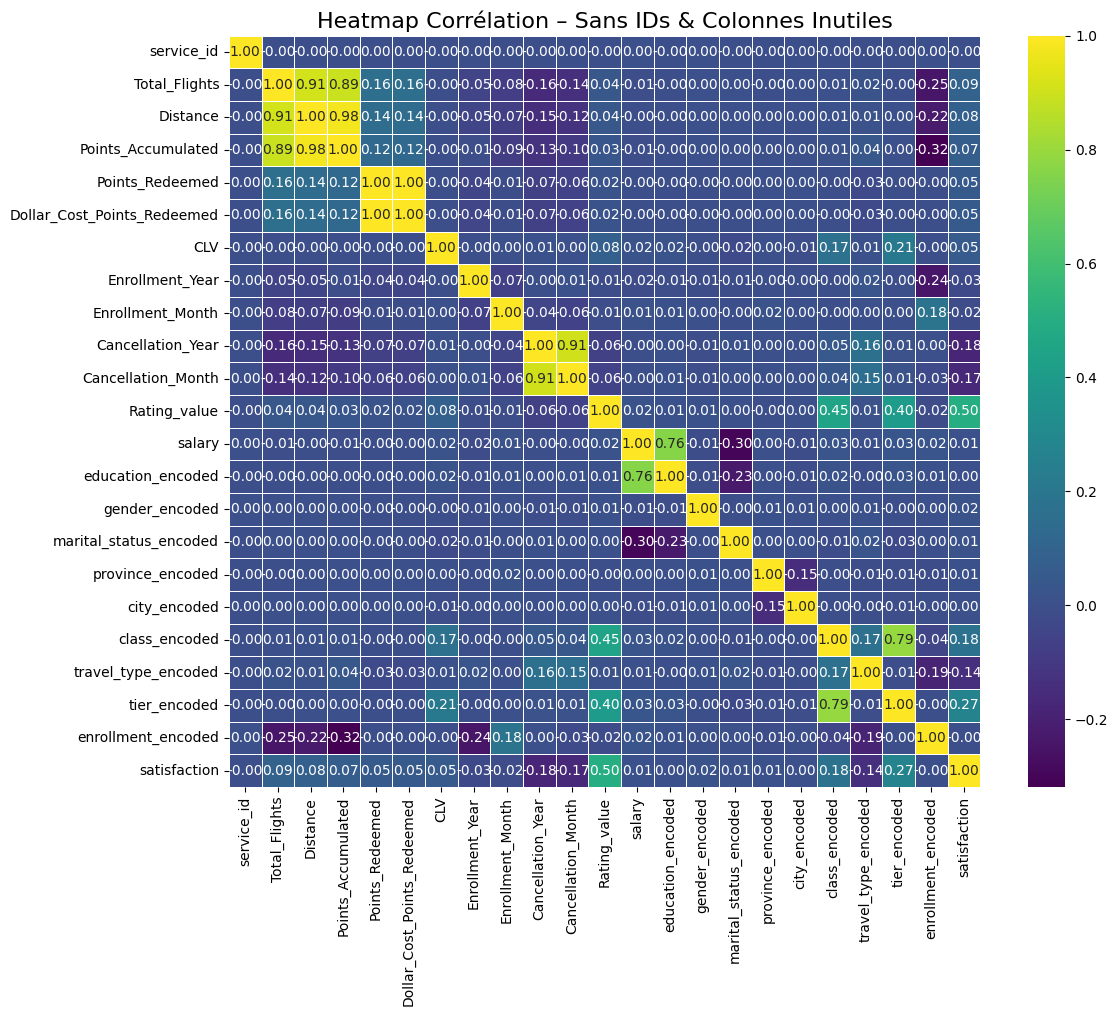

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Charger le bon dataset
#df = pd.read_csv("cleaned_master.csv")

# 📌 1. Retirer les colonnes ID (inutiles pour corrélation)
cols_to_drop = [
    "customer_id",
    "date_id",
    "flight_id",
    "loyalty_prog_id",
    "feedback_id"
]

df = master.drop(columns=[c for c in cols_to_drop if c in master.columns])

# 📌 2. Garder seulement les colonnes numériques utiles
df_num = df.select_dtypes(include=['int64', 'float64'])

# 📌 3. Calculer la corrélation
corr = df_num.corr()

# 📌 4. Heatmap propre et lisible
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap="viridis",
    linewidths=0.5,
    square=True
)
plt.title("Heatmap Corrélation – Sans IDs & Colonnes Inutiles", fontsize=16)
plt.tight_layout()
plt.show()
master.to_csv('asma_cleanned.csv', index=False)

In [82]:
master.info()
master.shape

In [83]:
master.to_csv('cleaned_master.csv', index=False)

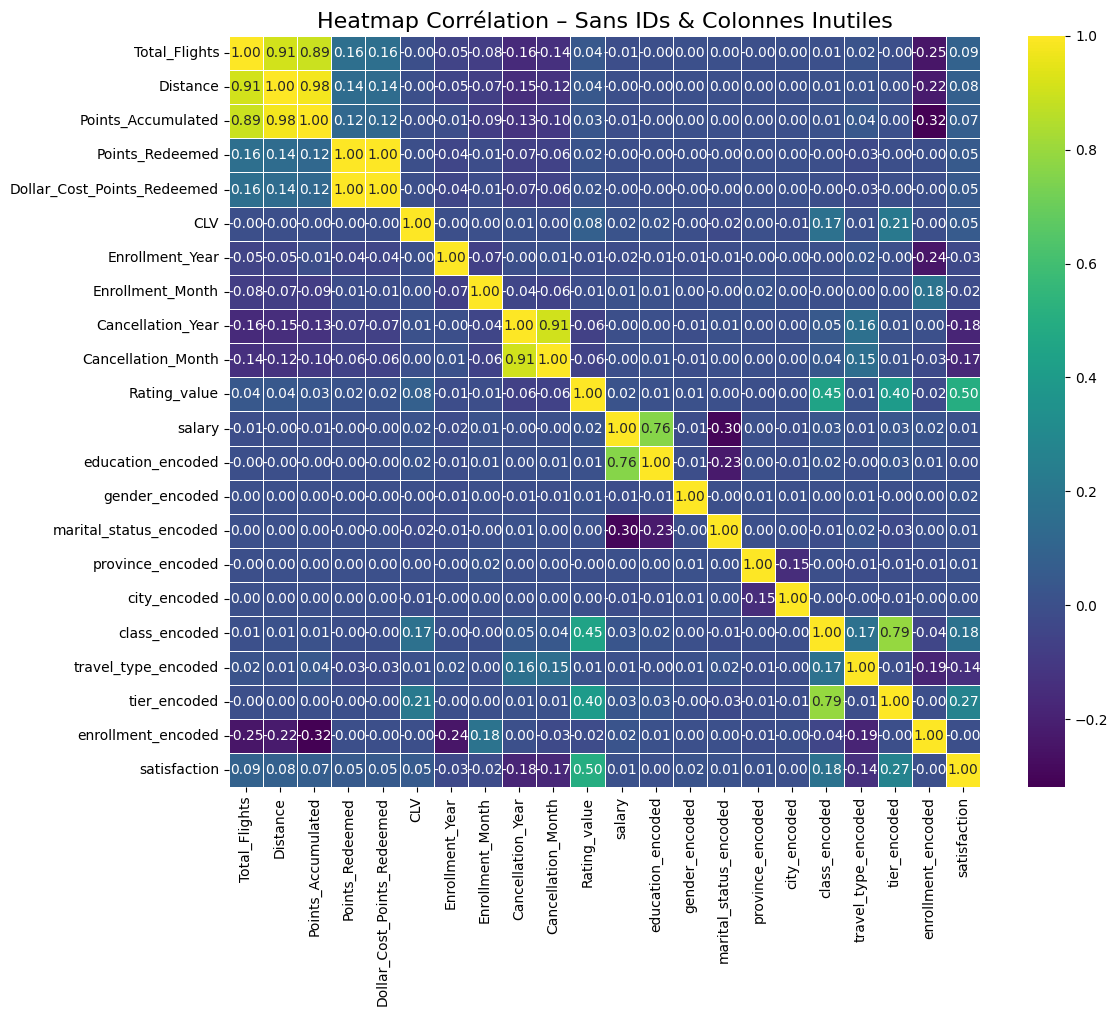

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Charger le bon dataset
df = pd.read_csv("cleaned_master.csv")

# 📌 1. Retirer les colonnes ID (inutiles pour corrélation)
cols_to_drop = [
    "customer_id",
    "date_id",
    "flight_id",
#   "service_id",
    "loyalty_prog_id",
    "feedback_id"
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 📌 2. Garder seulement les colonnes numériques utiles
df_num = df.select_dtypes(include=['int64', 'float64'])

# 📌 3. Calculer la corrélation
corr = df_num.corr()

# 📌 4. Heatmap propre et lisible
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap="viridis",
    linewidths=0.5,
    square=True
)
plt.title("Heatmap Corrélation – Sans IDs & Colonnes Inutiles", fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df[['Points_Accumulated','Total_Flights','Distance','CLV','salary']]

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)


              feature        VIF
0  Points_Accumulated  28.433177
1       Total_Flights   8.074696
2            Distance  35.018541
3                 CLV   1.718604
4              salary   1.786826


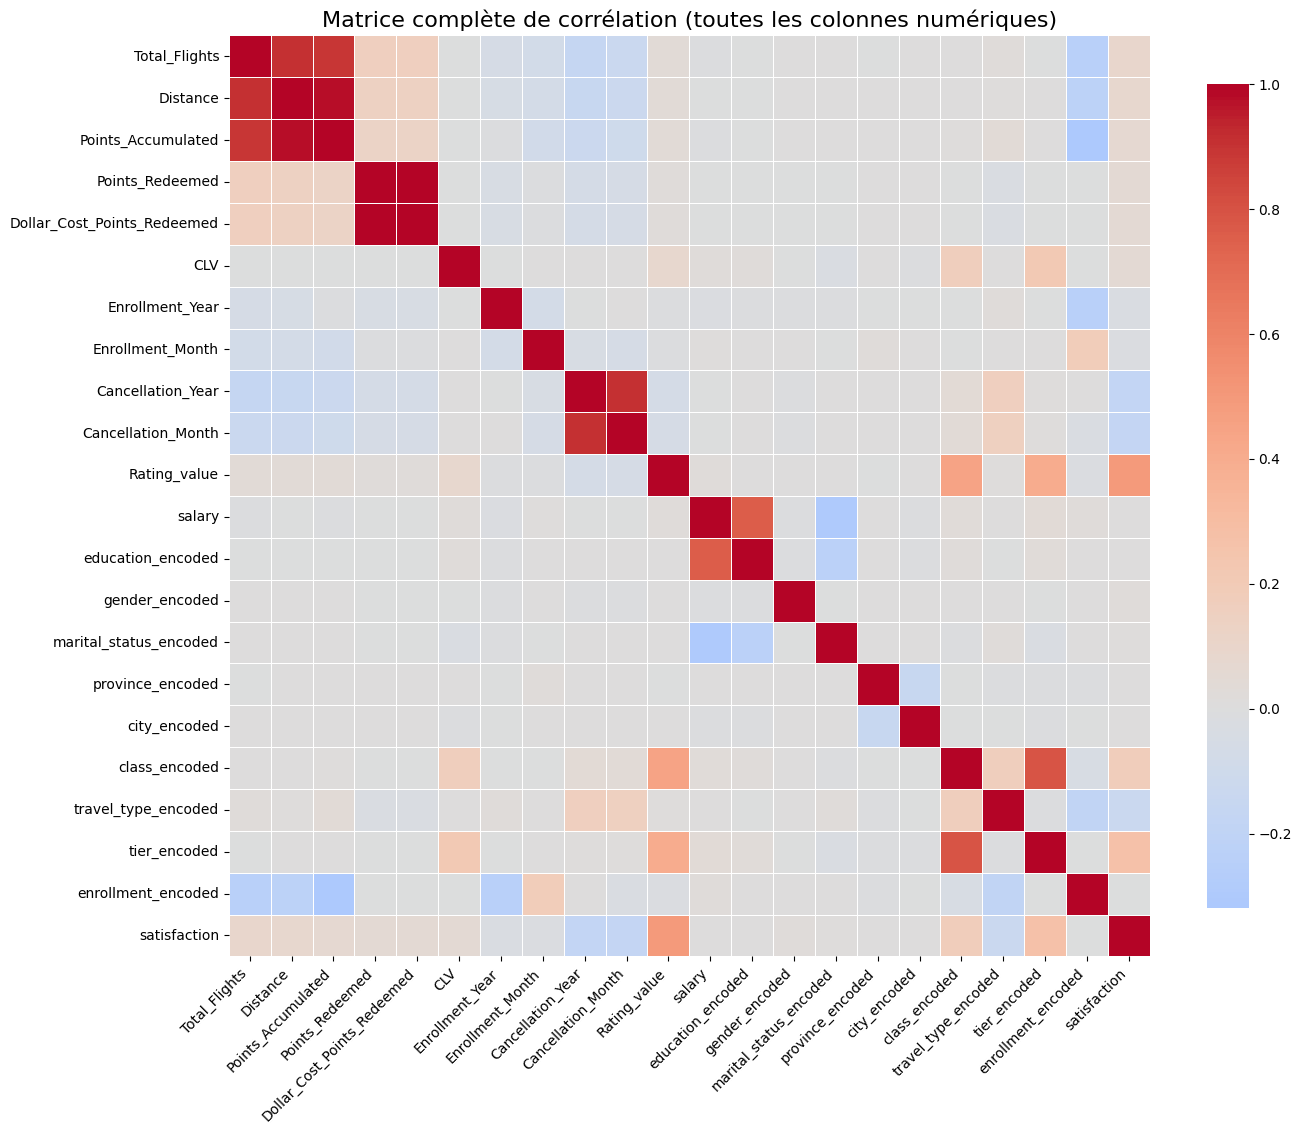

=== Top 20 paires de colonnes les plus corrélées (valeur absolue) ===
Total_Flights                Total_Flights                  1.000000
Distance                     Distance                       1.000000
Points_Accumulated           Points_Accumulated             1.000000
Points_Redeemed              Points_Redeemed                1.000000
Dollar_Cost_Points_Redeemed  Dollar_Cost_Points_Redeemed    1.000000
CLV                          CLV                            1.000000
Enrollment_Year              Enrollment_Year                1.000000
Cancellation_Year            Cancellation_Year              1.000000
Enrollment_Month             Enrollment_Month               1.000000
Cancellation_Month           Cancellation_Month             1.000000
education_encoded            education_encoded              1.000000
salary                       salary                         1.000000
Rating_value                 Rating_value                   1.000000
gender_encoded               gend

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sélectionner uniquement les colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()


numeric_cols = [col for col in numeric_cols]

# Vérifier qu'on a des colonnes
if len(numeric_cols) == 0:
    raise ValueError("Aucune colonne numérique trouvée !")

# 2. Calculer la matrice de corrélation
corr_matrix = df[numeric_cols].corr()

# 3. Afficher la heatmap complète
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=False,           # mettez True si vous voulez les chiffres (mais lent sur 30+ colonnes)
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)
plt.title('Matrice complète de corrélation (toutes les colonnes numériques)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Extraire les paires les plus corrélées (en valeur absolue), sauf diagonale
def get_redundant_pairs(df_corr):
    """Identifie les paires redondantes dans la matrice de corrélation"""
    pairs_to_drop = set()
    cols = df_corr.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df_corr, n=20):
    """Renvoie les n paires les plus fortement corrélées (absolue)"""
    au_corr = df_corr.abs().unstack()
    labels_to_drop = get_redundant_pairs(df_corr)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr.head(n)

# Afficher les top 20 paires les plus corrélées
print("=== Top 20 paires de colonnes les plus corrélées (valeur absolue) ===")
top_corr = get_top_abs_correlations(corr_matrix, n=30)
print(top_corr)

# 5. (Optionnel) Sauvegarder la matrice complète
# corr_matrix.to_csv("full_correlation_matrix.csv")

=== Top 15 features les plus corrélées (en valeur absolue) avec CLV ===
Dollar_Cost_Points_Redeemed    0.999995
Total_Flights                  0.155392
Distance                       0.139905
Points_Accumulated             0.122261
Cancellation_Year              0.065271
Cancellation_Month             0.056627
satisfaction                   0.046682
Enrollment_Year                0.042857
travel_type_encoded            0.025302
Rating_value                   0.017461
Enrollment_Month               0.014239
enrollment_encoded             0.004875
class_encoded                  0.004868
salary                         0.000998
education_encoded              0.000623
province_encoded               0.000538
marital_status_encoded         0.000456
city_encoded                   0.000380
tier_encoded                   0.000247
CLV                            0.000147
gender_encoded                 0.000092
Name: Points_Redeemed, dtype: float64


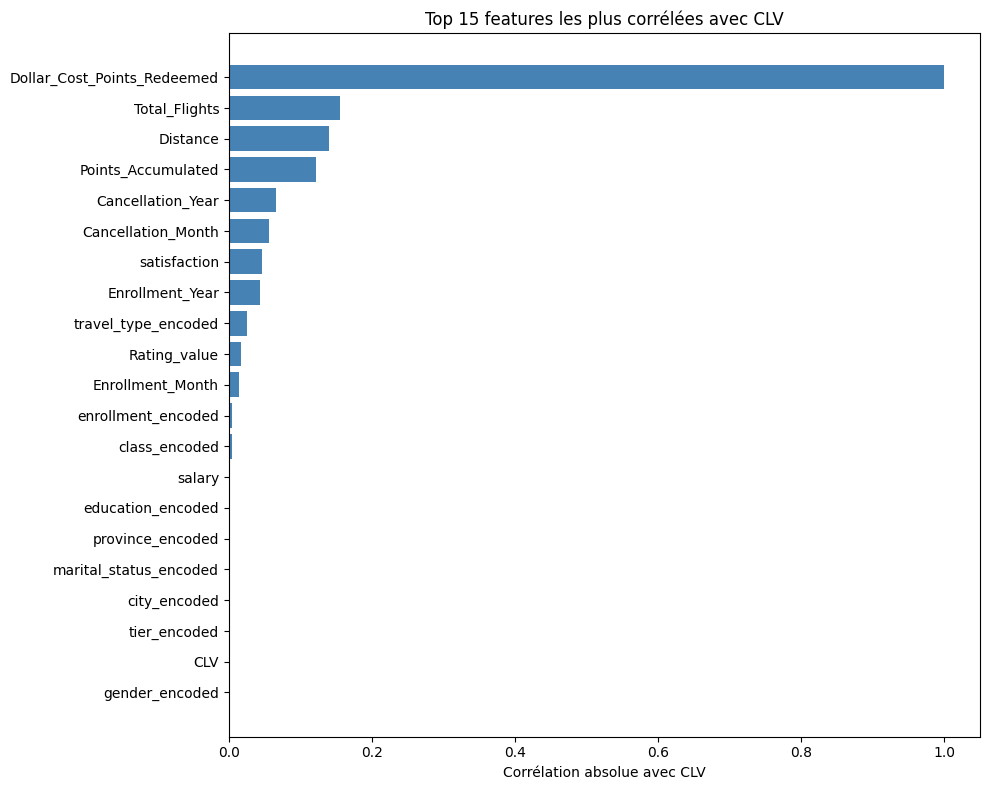

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sélectionner uniquement les colonnes numériques (et garder CLV)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Si 'CLV' n'est pas dans numeric_cols, il y a un problème
if 'Points_Redeemed' not in numeric_cols:
    raise ValueError("La colonne 'Points_Redeemed' est manquante ou non numérique !")

# 2. Calculer la corrélation absolue avec Points_Redeemed
corr_with_clv = df[numeric_cols].corr()['Points_Redeemed'].abs().sort_values(ascending=False)

# Retirer CLV lui-même
corr_with_clv = corr_with_clv.drop('Points_Redeemed')

# 3. Afficher les top 15 corrélations
print("=== Top 15 features les plus corrélées (en valeur absolue) avec CLV ===")
print(corr_with_clv.head(35))

# 4. Visualisation : barplot horizontal
plt.figure(figsize=(10, 8))
top_n = 35
top_features = corr_with_clv.head(top_n)

plt.barh(top_features.index, top_features.values, color='steelblue')
plt.xlabel('Corrélation absolue avec CLV')
plt.title('Top 15 features les plus corrélées avec CLV')
plt.gca().invert_yaxis()  # Meilleure feature en haut
plt.tight_layout()
plt.show()

# 5. (Optionnel) Sauvegarder les corrélations
# corr_with_clv.to_csv("correlation_with_clv.csv")